# AgroVision Plant Disease Detection using EfficientNet

Dataset → Cleaning → Preprocessing → Augmentation → EfficientNet Training → Evaluation → Prediction Pipeline

---
## 🔁 Resumable Training Strategy
| Session | Epochs | Action |
|---------|--------|--------|
| Session 1 | 0 → 3 | Train fresh, save to Drive |
| Session 2 | 3 → 6 | Load from Drive, train 3 more, save |
| Session 3 | 6 → 8 | Load from Drive, train 2 more, save |
| ... | ... | Keep going until 98 total epochs |

> ✅ Just run the **same notebook every session** — it auto-detects where you left off!

## 📦 Step 1: One-Time Setup — Kaggle API & Dataset Download
> ⚠️ Only run this section ONCE to download and extract the dataset.

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

from google.colab import files
print("📤 Upload kaggle.json")
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!apt-get install -y p7zip-full

ZIP_PATH = "/content/dataset.zip"
EXTRACT_PATH = "/content/dataset"

print("\n⬇️ Downloading dataset...")
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset -p /content
!mv /content/new-plant-diseases-dataset.zip "{ZIP_PATH}"

if os.path.exists(EXTRACT_PATH):
    !rm -rf "{EXTRACT_PATH}"
os.makedirs(EXTRACT_PATH, exist_ok=True)

print("\n📦 Extracting dataset...")
!7z x "{ZIP_PATH}" -o"{EXTRACT_PATH}"

print("\n✅ DONE!")
print(os.listdir(EXTRACT_PATH))

📤 Upload kaggle.json


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.

⬇️ Downloading dataset...
Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [03:12<00:00, 15.1MB/s]


📦 Extracting dataset...

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/                   1 file, 2897709187 bytes (2764 MiB)

Extracting archive: /content/dataset.zip
  2% 4096 Open              --
Path = /content/dataset.zip
Type = zip
Physical Size = 2897709187
64-bit = +

  0%      0% 570          0% 8

## 📊 Step 2: Data Understanding

In [ ]:
import os

dataset_path = "/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

def count_images(folder):
    total = 0
    per_class = {}
    for cls in sorted(os.listdir(folder)):
        cls_path = os.path.join(folder, cls)
        if not os.path.isdir(cls_path):
            continue
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        per_class[cls] = len(images)
        total += len(images)
    return total, per_class

train_path = os.path.join(dataset_path, "train")
valid_path = os.path.join(dataset_path, "valid")

train_total, train_counts = count_images(train_path)
valid_total, valid_counts = count_images(valid_path)
classes = list(train_counts.keys())

print("📊 DATASET SUMMARY")
print("Total classes:", len(train_counts))
print("Train images:", train_total)
print("Validation images:", valid_total)

📊 DATASET SUMMARY
Total classes: 38
Train images: 70295
Validation images: 17572


In [ ]:
import pandas as pd

df = pd.DataFrame({"Train": train_counts, "Validation": valid_counts})
df = df.fillna(0).astype(int)
df["Total"] = df["Train"] + df["Validation"]
df = df.sort_values(by="Total", ascending=False).reset_index().rename(columns={"index": "Class"})
df.head(10)

,Class,Train,Validation,Total
0,Soybean___healthy,2022,505,2527
1,Apple___Apple_scab,2016,504,2520
2,Orange___Haunglongbing_(Citrus_greening),2010,503,2513
3,Apple___healthy,2008,502,2510
4,"Pepper,_bell___healthy",1988,497,2485
5,Apple___Black_rot,1987,497,2484
6,Tomato___Tomato_Yellow_Leaf_Curl_Virus,1961,490,2451
7,Potato___Late_blight,1939,485,2424
8,Potato___Early_blight,1939,485,2424
9,Tomato___healthy,1926,481,2407


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

plt.figure(figsize=(12, 8))
for i in range(6):
    cls = random.choice(classes)
    cls_path = os.path.join(train_path, cls)
    imgs = [f for f in os.listdir(cls_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    if not imgs:
        continue
    try:
        with Image.open(os.path.join(cls_path, random.choice(imgs))) as img:
            plt.subplot(2, 3, i + 1)
            plt.imshow(img)
            plt.title(cls[:30])
            plt.axis("off")
    except:
        continue
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

## ✂️ Step 3: Dataset Splitting (Train / Valid / Test)

In [ ]:
import os, shutil, random
from tqdm import tqdm

def split_dataset(dataset_path, output_path, train_ratio=0.8):
    random.seed(42)
    if os.path.exists(output_path):
        shutil.rmtree(output_path)
    os.makedirs(output_path, exist_ok=True)

    train_out = os.path.join(output_path, "train")
    valid_out = os.path.join(output_path, "valid")
    test_out  = os.path.join(output_path, "test")
    for p in [train_out, valid_out, test_out]:
        os.makedirs(p, exist_ok=True)

    train_src = os.path.join(dataset_path, "train")
    valid_src = os.path.join(dataset_path, "valid")

    for cls in tqdm(os.listdir(train_src), desc="Splitting train"):
        src_cls = os.path.join(train_src, cls)
        if not os.path.isdir(src_cls):
            continue
        images = [f for f in os.listdir(src_cls) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        random.shuffle(images)
        split_idx = int(len(images) * train_ratio)
        os.makedirs(os.path.join(train_out, cls), exist_ok=True)
        os.makedirs(os.path.join(test_out, cls), exist_ok=True)
        for img in images[:split_idx]:
            shutil.copy2(os.path.join(src_cls, img), os.path.join(train_out, cls, img))
        for img in images[split_idx:]:
            shutil.copy2(os.path.join(src_cls, img), os.path.join(test_out, cls, img))

    for cls in tqdm(os.listdir(valid_src), desc="Copying validation"):
        src_cls = os.path.join(valid_src, cls)
        if not os.path.isdir(src_cls):
            continue
        dst_cls = os.path.join(valid_out, cls)
        os.makedirs(dst_cls, exist_ok=True)
        for img in os.listdir(src_cls):
            if img.lower().endswith(('.jpg', '.jpeg', '.png')):
                shutil.copy2(os.path.join(src_cls, img), os.path.join(dst_cls, img))

    print("✅ Split complete!")

output_path = "/content/final_dataset"
split_dataset(dataset_path, output_path, train_ratio=0.8)

Copying validation: 100%|██████████| 38/38 [00:02<00:00, 16.54it/s]

✅ Split complete!


In [ ]:
subset_path = "/content/final_dataset"
train_path = os.path.join(subset_path, "train")
valid_path = os.path.join(subset_path, "valid")
test_path  = os.path.join(subset_path, "test")

train_total, train_counts = count_images(train_path)
valid_total, valid_counts = count_images(valid_path)
test_total,  test_counts  = count_images(test_path)

print("📦 FINAL DATASET SUMMARY")
print("Total classes:", len(train_counts))
print("Train:", train_total, "| Valid:", valid_total, "| Test:", test_total)
print("Train/Test ratio:", round(train_total / (train_total + test_total), 2))

📦 FINAL DATASET SUMMARY
Total classes: 38
Train: 56219 | Valid: 17572 | Test: 14076
Train/Test ratio: 0.8


## 🧹 Step 4: Cleaning

In [ ]:
from PIL import Image
from tqdm import tqdm

def remove_corrupted_images(folder):
    removed = 0
    image_paths = []
    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(root, file))
    print(f"📊 Total images to check: {len(image_paths)}")
    for path in tqdm(image_paths, desc="Checking images"):
        try:
            with Image.open(path) as img:
                img.verify()
        except:
            os.remove(path)
            removed += 1
    print("✅ Done | Corrupted removed:", removed)

remove_corrupted_images("/content/final_dataset")

📊 Total images to check: 87867


Checking images: 100%|██████████| 87867/87867 [00:05<00:00, 16192.09it/s]

✅ Done | Corrupted removed: 0


In [ ]:
valid_ext = (".jpg", ".jpeg", ".png")
removed = 0
file_paths = []
for root, _, files in os.walk("/content/final_dataset"):
    for file in files:
        file_paths.append(os.path.join(root, file))
print(f"📊 Total files found: {len(file_paths)}")
for path in tqdm(file_paths, desc="Cleaning non-image files"):
    if not path.lower().endswith(valid_ext):
        try:
            os.remove(path)
            removed += 1
        except:
            continue
print("✅ Done | Non-image files removed:", removed)

📊 Total files found: 87867


Cleaning non-image files: 100%|██████████| 87867/87867 [00:00<00:00, 1923792.40it/s]

✅ Done | Non-image files removed: 0


## ⚙️ Step 5: Imports & Config

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

# ── Config ──────────────────────────────────────────────────
IMG_SIZE     = 224
BATCH_SIZE   = 32
TOTAL_EPOCHS = 98        # 🎯 final target — spread across all sessions

TRAIN_PATH = "/content/final_dataset/train"
VALID_PATH = "/content/final_dataset/valid"
TEST_PATH  = "/content/final_dataset/test"

# 💾 Google Drive — checkpoint folder
SAVE_DIR     = "/content/drive/MyDrive/agrovision_checkpoint"
WEIGHTS_FILE = os.path.join(SAVE_DIR, "model_weights.h5")
EPOCH_FILE   = os.path.join(SAVE_DIR, "epochs_done.txt")

print("✅ Config ready | TF version:", tf.__version__)

✅ Config ready | TF version: 2.19.0


## 📂 Step 6: Data Generators

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.6, 1.4],
    channel_shift_range=40,
    fill_mode="nearest"
)

valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

valid_gen = valid_datagen.flow_from_directory(
    VALID_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

print("Train batches:", len(train_gen))
print("Valid batches:", len(valid_gen))

Found 56219 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Train batches: 1757
Valid batches: 550


## 🧠 Step 7: Build Model

In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(38, activation="softmax")   # 38 plant disease classes
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,392,393 (16.76 MB)

 Trainable params: 340,262 (1.30 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 🔁 Step 8: Resumable Training

### How it works:
| Session | Set `EPOCHS_THIS_SESSION` to | Result |
|---------|-------------------------------|--------|
| Session 1 | `3` | Trains epochs 0–2, saves |
| Session 2 | `3` | Loads weights, trains epochs 3–5, saves |
| Session 3 | `2` | Loads weights, trains epochs 6–7, saves |
| Session 4+ | any number | Keeps going from last saved point |

> 🔧 **Only change `EPOCHS_THIS_SESSION`** at the top of the cell each session. Everything else is automatic.

In [ ]:
  # ============================================================
# 🔁 RESUMABLE TRAINING — SAFE & AUTO-CHECKPOINT VERSION
# ============================================================

# ✏️ ONLY change this each session
EPOCHS_THIS_SESSION = 3

from google.colab import drive
import os
from keras.callbacks import ModelCheckpoint, EarlyStopping

drive.mount('/content/drive')
os.makedirs(SAVE_DIR, exist_ok=True)

# ✅ FIX: correct filename (MANDATORY)
WEIGHTS_FILE = os.path.join(SAVE_DIR, "model.weights.h5")

# ── Callbacks (AUTO SAVE + SMART STOP) ──────────────────────
checkpoint_cb = ModelCheckpoint(
    WEIGHTS_FILE,
    save_weights_only=True,
    save_freq='epoch',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True
)

# ── Load previous progress ──────────────────────────────────
if os.path.exists(EPOCH_FILE) and os.path.exists(WEIGHTS_FILE):
    with open(EPOCH_FILE) as f:
        epochs_done = int(f.read().strip())
    model.load_weights(WEIGHTS_FILE)
    print(f"🔄 Checkpoint loaded! Completed: {epochs_done} epochs")
else:
    epochs_done = 0
    print("🆕 Starting fresh from epoch 0")

print(f"▶️ This session: {epochs_done} → {epochs_done + EPOCHS_THIS_SESSION}")

# ── Prevent over-training ───────────────────────────────────
if epochs_done >= TOTAL_EPOCHS:
    print(f"🎉 Already completed all {TOTAL_EPOCHS} epochs!")
else:
    end_epoch = min(epochs_done + EPOCHS_THIS_SESSION, TOTAL_EPOCHS)

    # ── Train ───────────────────────────────────────────────
    history = model.fit(
        train_gen,
        validation_data=valid_gen,
        epochs=end_epoch,
        initial_epoch=epochs_done,
        callbacks=[checkpoint_cb, early_stop]   # 🔥 SAFE TRAINING
    )

    # ── Save epoch progress (ALWAYS runs) ───────────────────
    with open(EPOCH_FILE, "w") as f:
        f.write(str(end_epoch))

    print(f"\n✅ Session complete!")
    print(f"💾 Weights auto-saved to: {WEIGHTS_FILE}")
    print(f"📈 Done: {end_epoch}/{TOTAL_EPOCHS}")
    print(f"📉 Remaining: {TOTAL_EPOCHS - end_epoch}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Exception ignored in: <function WeakValueDictionary.__init__.<locals>.remove at 0x7e63f281f240>
Traceback (most recent call last):
  File "/usr/lib/python3.12/weakref.py", line 105, in remove
    def remove(wr, selfref=ref(self), _atomic_removal=_remove_dead_weakref):

KeyboardInterrupt: 


KeyboardInterrupt: 

In [ ]:
# model.save_weights("/content/drive/MyDrive/agrovision_checkpoint/model.weights.h5")

# with open(EPOCH_FILE, "w") as f:
#     f.write("3")

## 📈 Step 9: Plot Training History
> Run after each session to see accuracy & loss for this session's epochs.

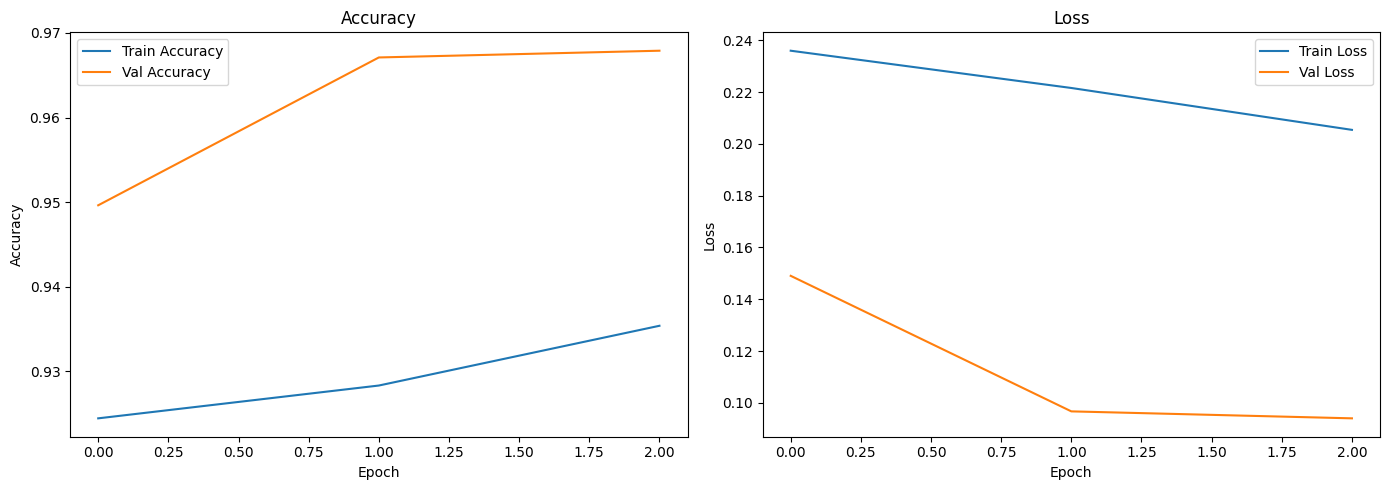

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## ✅ Step 10: Evaluation
> Run this after enough training epochs to check model quality.

In [ ]:
loss, acc = model.evaluate(valid_gen)
print(f"Validation Accuracy : {acc*100:.2f}%")
print(f"Validation Loss     : {loss:.4f}")

550/550 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.9503 - loss: 0.1435
Validation Accuracy : 95.03%
Validation Loss     : 0.1435


## 🔢 Step 11: Confusion Matrix

550/550 ━━━━━━━━━━━━━━━━━━━━ 50s 72ms/step


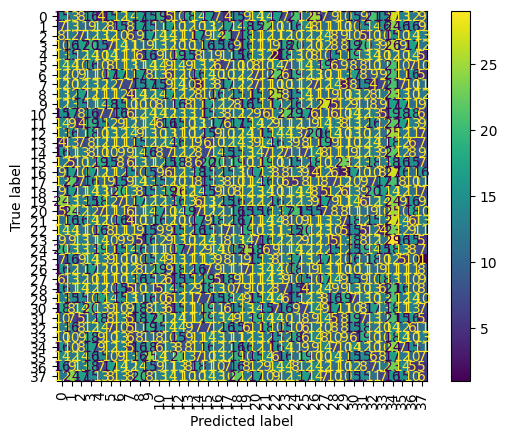

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(valid_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = valid_gen.classes

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation=90)
plt.show()

## 🖼️ Step 12: Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


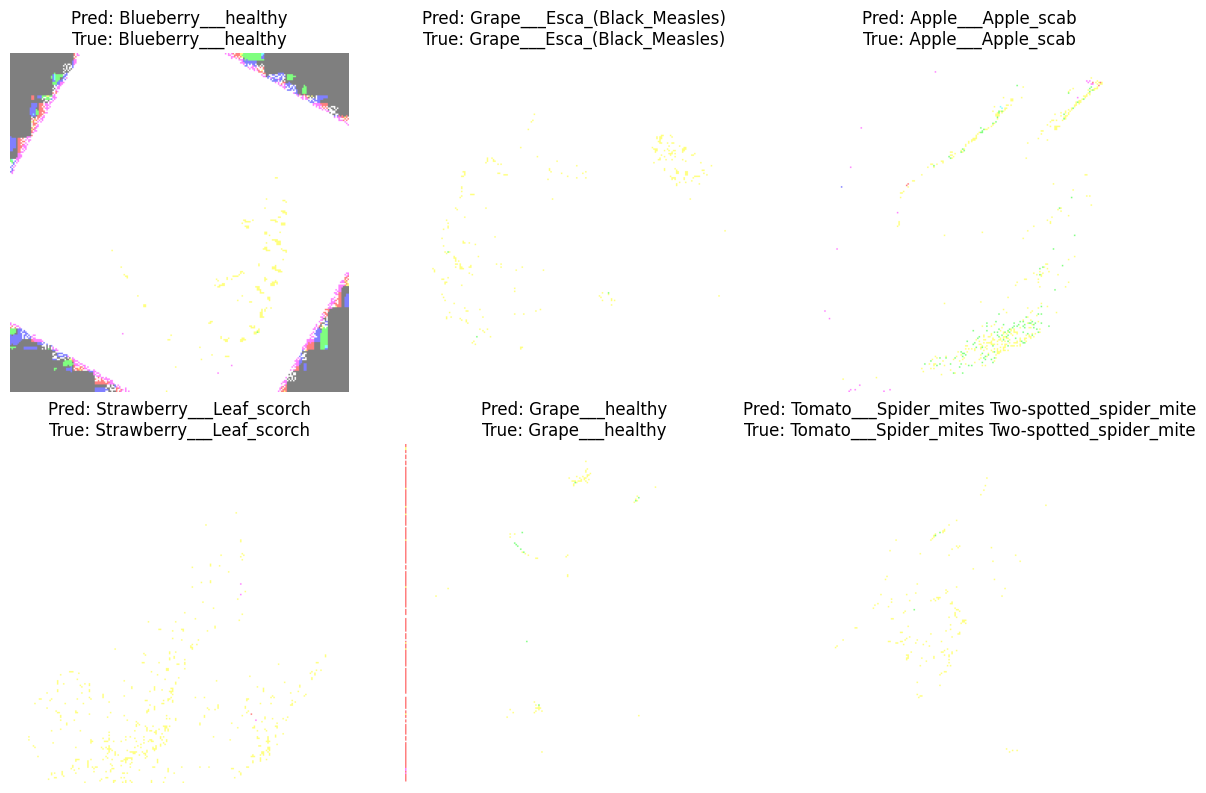

In [ ]:
class_names = list(train_gen.class_indices.keys())

x_batch, y_batch = next(valid_gen)
preds = model.predict(x_batch)
pred_classes = preds.argmax(axis=1)
true_classes = y_batch.argmax(axis=1)

plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    img = (x_batch[i] + 1) / 2
    plt.imshow(img)
    plt.title(f"Pred: {class_names[pred_classes[i]]}\nTrue: {class_names[true_classes[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## 🧪 Step 13: Test Set Prediction

In [ ]:
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=False
)

preds = model.predict(test_gen)
pred_classes = np.argmax(preds, axis=1)
pred_labels = [class_names[i] for i in pred_classes]

print("Total test images:", test_gen.samples)
print("Sample predictions:", pred_labels[:10])

Found 14076 images belonging to 38 classes.
440/440 ━━━━━━━━━━━━━━━━━━━━ 49s 97ms/step
Total test images: 14076
Sample predictions: ['Apple___Apple_scab', 'Apple___Apple_scab', 'Apple___Apple_scab', 'Apple___Apple_scab', 'Apple___Apple_scab', 'Apple___healthy', 'Apple___Apple_scab', 'Apple___Apple_scab', 'Apple___Apple_scab', 'Apple___Apple_scab']


## 🔍 Step 14: Single Image Prediction Pipeline

In [ ]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    pred = model.predict(img_array)
    class_idx = np.argmax(pred)
    confidence = float(pred[0][class_idx]) * 100
    return class_names[class_idx], round(confidence, 2)

# Example
test_img = test_gen.filepaths[0]
label, conf = predict_image(test_img)
print(f"Prediction : {label}")
print(f"Confidence : {conf}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
Prediction : Apple___Apple_scab
Confidence : 98.58%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Label: Apple___Cedar_apple_rust
Confidence: 100.00%


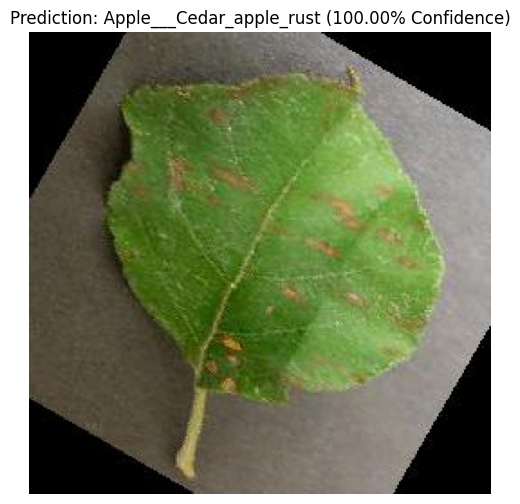

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# @title 🖼️ Custom Image Prediction
# ⬇️ Paste the path to your image file here
custom_image_path = "/content/final_dataset/test/Apple___Cedar_apple_rust/025b2b9a-0ec4-4132-96ac-7f2832d0db4a___FREC_C.Rust 3655_new30degFlipLR.JPG" #@param {type:"string"}

predicted_label, confidence = predict_image(custom_image_path)

print(f"Predicted Label: {predicted_label}")
print(f"Confidence: {confidence:.2f}%")

# Visualize the image with the prediction
plt.figure(figsize=(6, 6))
img_display = Image.open(custom_image_path)
plt.imshow(img_display)
plt.title(f"Prediction: {predicted_label} ({confidence:.2f}% Confidence)")
plt.axis("off")
plt.show()